In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df_train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [3]:
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

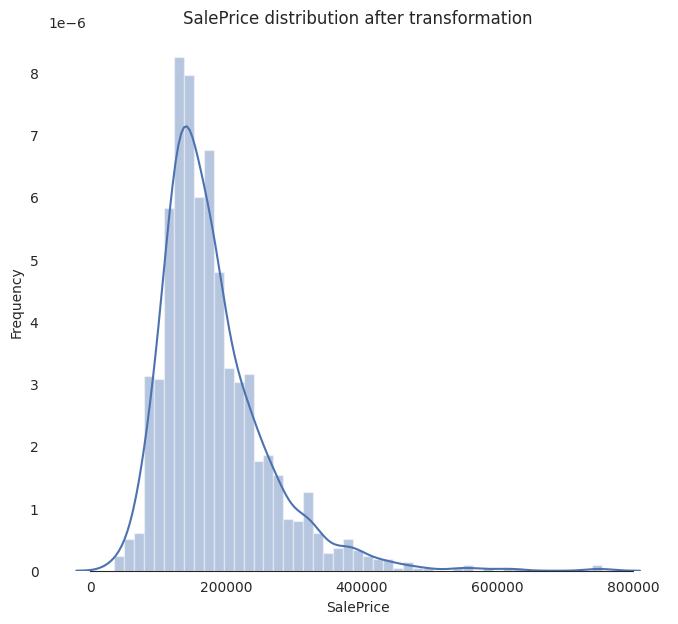

Skewness: 1.882876


In [4]:
sns.set_style("white")
sns.set_color_codes(palette='deep')
f, ax = plt.subplots(figsize=(8, 7))
sns.distplot(df_train['SalePrice'], color="b");
ax.xaxis.grid(False)
ax.set(ylabel="Frequency")
ax.set(xlabel="SalePrice")
ax.set(title="SalePrice distribution after transformation")
sns.despine(trim=True, left=True)
plt.show()
print("Skewness: %f" % df_train['SalePrice'].skew())

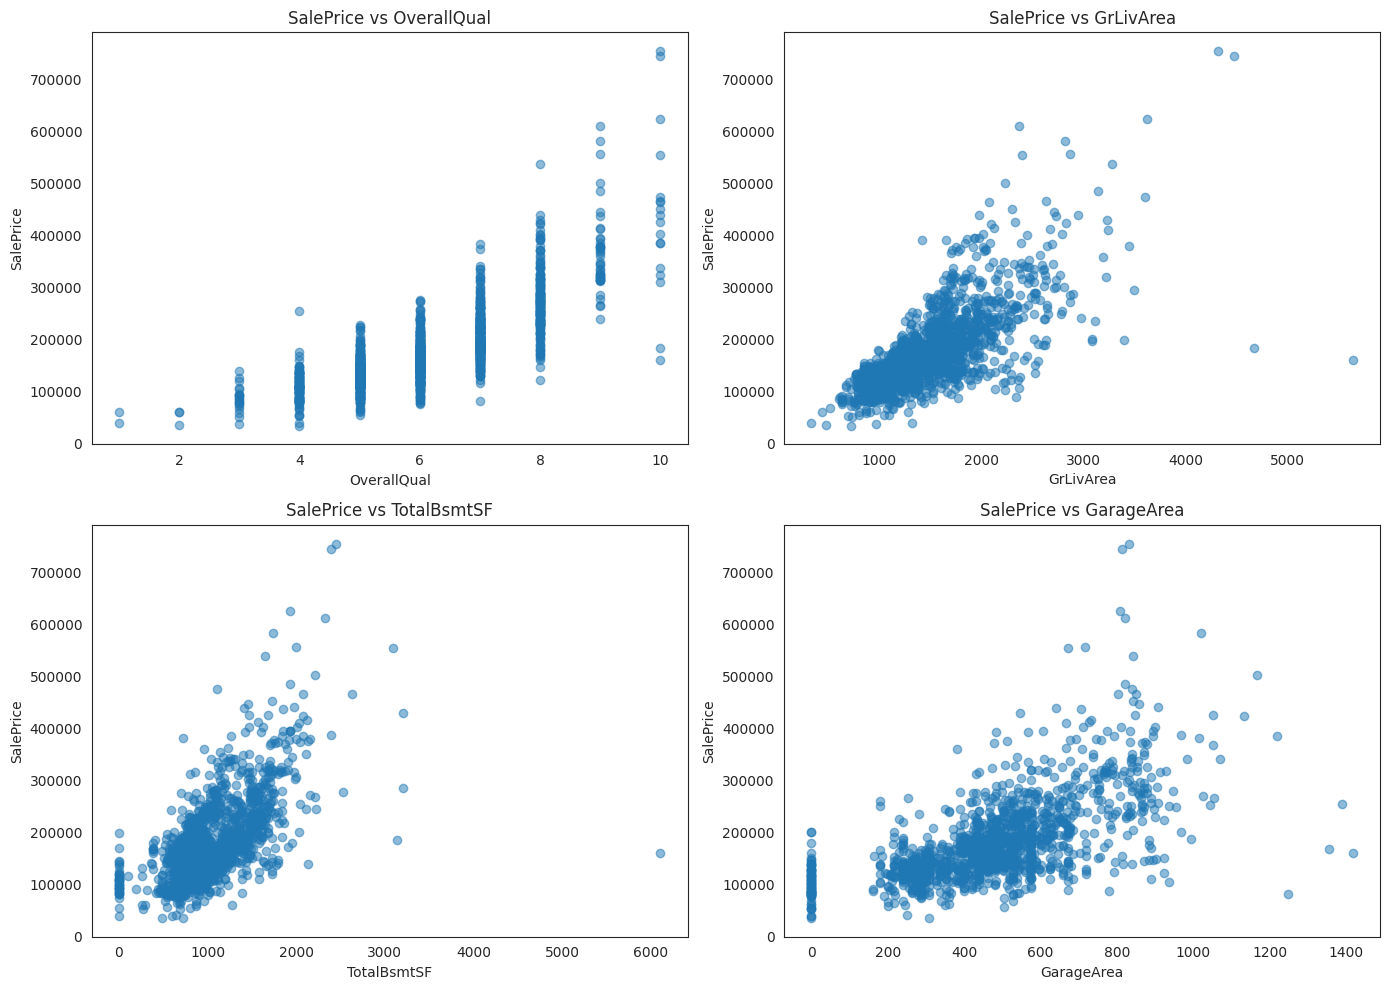

In [5]:
# Create a figure and set of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Scatterplot for SalePrice vs OverallQual
axs[0, 0].scatter(df_train['OverallQual'], df_train['SalePrice'], alpha=0.5)
axs[0, 0].set_title('SalePrice vs OverallQual')
axs[0, 0].set_xlabel('OverallQual')
axs[0, 0].set_ylabel('SalePrice')

# Scatterplot for SalePrice vs GrLivArea
axs[0, 1].scatter(df_train['GrLivArea'], df_train['SalePrice'], alpha=0.5)
axs[0, 1].set_title('SalePrice vs GrLivArea')
axs[0, 1].set_xlabel('GrLivArea')
axs[0, 1].set_ylabel('SalePrice')

# Scatterplot for SalePrice vs TotalBsmtSF
axs[1, 0].scatter(df_train['TotalBsmtSF'], df_train['SalePrice'], alpha=0.5)
axs[1, 0].set_title('SalePrice vs TotalBsmtSF')
axs[1, 0].set_xlabel('TotalBsmtSF')
axs[1, 0].set_ylabel('SalePrice')

# Scatterplot for SalePrice vs GarageArea
axs[1, 1].scatter(df_train['GarageArea'], df_train['SalePrice'], alpha=0.5)
axs[1, 1].set_title('SalePrice vs GarageArea')
axs[1, 1].set_xlabel('GarageArea')
axs[1, 1].set_ylabel('SalePrice')

# Adjust layout
plt.tight_layout()
plt.show()

In [6]:
num_rows = df_train.shape[0]
print(f'Number of rows: {num_rows}')

Number of rows: 1460


In [7]:
# Count rows with any missing values
num_rows_with_missing = df_train.isnull().any(axis=1).sum()
print(f'Number of rows with any missing values: {num_rows_with_missing}')

Number of rows with any missing values: 1460


In [8]:
#missing data
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [9]:
# Calculate the percentage of missing values for each column
missing_percentage = df_train.isnull().mean() * 100

# Create a DataFrame with columns and their missing value percentages
missing_df = pd.DataFrame({'Column': missing_percentage.index, 'MissingPercentage': missing_percentage.values})

# Sort by missing value percentage in descending order
missing_df = missing_df.sort_values(by='MissingPercentage', ascending=False)

# Identify the top 7 features with the highest missing value percentages
top_7_features = missing_df.head(7)['Column'].tolist()

# Drop these columns from the DataFrame in place
df_train.drop(columns=top_7_features, inplace=True)

# Display the columns removed
print("Columns removed:", top_7_features)
print("DataFrame after removing columns with the top 7 highest missing values:")
print(df_train.head())

Columns removed: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage']
DataFrame after removing columns with the top 7 highest missing values:
   Id  MSSubClass MSZoning  LotArea Street LotShape LandContour Utilities  \
0   1          60       RL     8450   Pave      Reg         Lvl    AllPub   
1   2          20       RL     9600   Pave      Reg         Lvl    AllPub   
2   3          60       RL    11250   Pave      IR1         Lvl    AllPub   
3   4          70       RL     9550   Pave      IR1         Lvl    AllPub   
4   5          60       RL    14260   Pave      IR1         Lvl    AllPub   

  LotConfig LandSlope  ... EnclosedPorch 3SsnPorch ScreenPorch PoolArea  \
0    Inside       Gtl  ...             0         0           0        0   
1       FR2       Gtl  ...             0         0           0        0   
2    Inside       Gtl  ...             0         0           0        0   
3    Corner       Gtl  ...           272         0          

In [10]:
df_train.fillna(df_train.mode().iloc[0], inplace=True)

In [11]:
# Filter out non-numeric columns
numeric_df = df_train.select_dtypes(include=['number'])

# Calculate Q1 and Q3 for numerical columns
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

# Count the number of outlier rows
num_outliers = outliers.sum()
print(f"Number of outlier rows: {num_outliers}")

Number of outlier rows: 884


In [12]:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])

In [13]:
# Function to calculate the percentage of outliers in a feature
def percentage_outliers(df_train, feature):
    Q1 = df_train[feature].quantile(0.25)
    Q3 = df_train[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    total_rows = df_train.shape[0]
    outliers_count = df_train[(df_train[feature] < lower_bound) | (df_train[feature] > upper_bound)].shape[0]
    outliers_percentage = (outliers_count / total_rows) * 100
    return outliers_percentage

# Iterate over all numerical features and calculate the percentage of outliers
outliers_summary = {}
for feature in df_train.select_dtypes(include=['float64', 'int64']).columns:
    outliers_summary[feature] = percentage_outliers(df_train, feature)

# Convert the summary to a DataFrame for better readability
outliers_summary_df = pd.DataFrame(list(outliers_summary.items()), columns=['Feature', 'Percentage of Outliers'])
print(outliers_summary_df)

          Feature  Percentage of Outliers
0              Id                0.000000
1      MSSubClass                7.054795
2         LotArea                4.726027
3     OverallQual                0.136986
4     OverallCond                8.561644
5       YearBuilt                0.479452
6    YearRemodAdd                0.000000
7      MasVnrArea                6.712329
8      BsmtFinSF1                0.479452
9      BsmtFinSF2               11.438356
10      BsmtUnfSF                1.986301
11    TotalBsmtSF                4.178082
12       1stFlrSF                1.369863
13       2ndFlrSF                0.136986
14   LowQualFinSF                1.780822
15      GrLivArea                2.123288
16   BsmtFullBath                0.068493
17   BsmtHalfBath                5.616438
18       FullBath                0.000000
19       HalfBath                0.000000
20   BedroomAbvGr                2.397260
21   KitchenAbvGr                4.657534
22   TotRmsAbvGrd                2

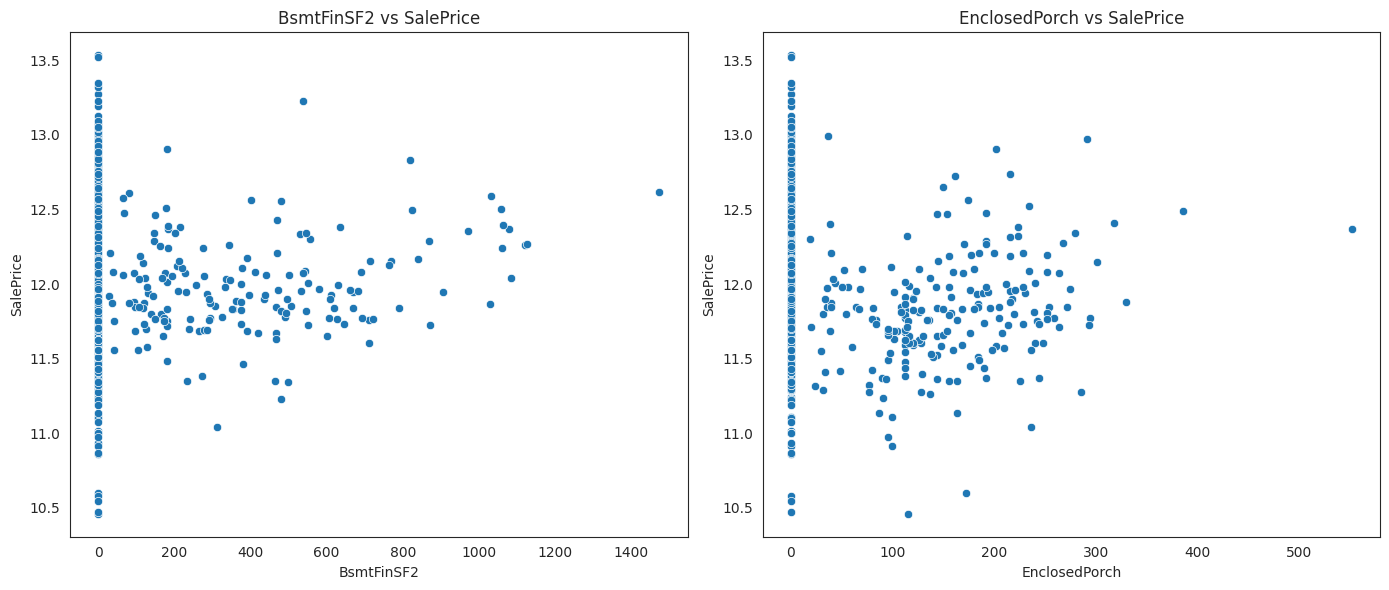

In [14]:
plt.figure(figsize=(14, 6))

# Create scatter plot for BsmtFinSF2 vs SalePrice
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_train['BsmtFinSF2'], y=df_train['SalePrice'])
plt.title('BsmtFinSF2 vs SalePrice')
plt.xlabel('BsmtFinSF2')
plt.ylabel('SalePrice')

# Create scatter plot for EnclosedPorch vs SalePrice
plt.subplot(1, 2, 2)
sns.scatterplot(x=df_train['EnclosedPorch'], y=df_train['SalePrice'])
plt.title('EnclosedPorch vs SalePrice')
plt.xlabel('EnclosedPorch')
plt.ylabel('SalePrice')

plt.tight_layout()

plt.show()

In [15]:
rf = RandomForestRegressor(n_estimators=1200,
                          max_depth=15,
                          min_samples_split=5,
                          min_samples_leaf=5,
                          max_features=None,
                          )

In [16]:
gbr = GradientBoostingRegressor(n_estimators=6000,
                                learning_rate=0.01,
                                max_depth=4,
                                max_features='sqrt',
                                min_samples_leaf=15,
                                min_samples_split=10,
                                )

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df_train.drop('SalePrice', axis=1)  # Assuming 'SalePrice' is the target variable
y = df_train['SalePrice']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Create transformers for numerical and categorical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))  # Impute missing values with median
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with most frequent value
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # OneHot encode categorical features
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Create pipelines for each model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=1200,
                                        max_depth=15,
                                        min_samples_split=5,
                                        min_samples_leaf=5,
                                        max_features=None,
                                        random_state=42))
])

gbr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=6000,
                                            learning_rate=0.01,
                                            max_depth=4,
                                            max_features='sqrt',
                                            min_samples_leaf=15,
                                            min_samples_split=10,
                                            random_state=42))
])

# Fit Random Forest model
rf_pipeline.fit(X_train, y_train)

# Fit Gradient Boosting Machine model
gbr_pipeline.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_pipeline.predict(X_test)
gbr_predictions = gbr_pipeline.predict(X_test)

# Evaluate models
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

gbr_mse = mean_squared_error(y_test, gbr_predictions)
gbr_r2 = r2_score(y_test, gbr_predictions)

print(f"Random Forest MSE: {rf_mse}, R^2: {rf_r2}")
print(f"Gradient Boosting Machine MSE: {gbr_mse}, R^2: {gbr_r2}")

Random Forest MSE: 0.022951436225769856, R^2: 0.8770091922276064
Gradient Boosting Machine MSE: 0.01794407902585438, R^2: 0.9038423237477607


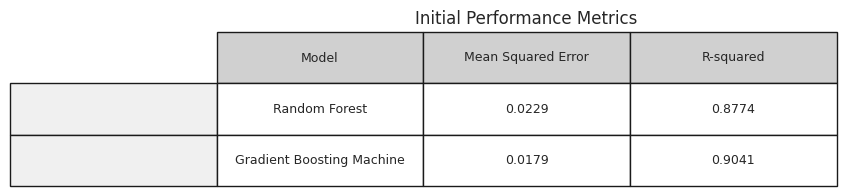

In [18]:
# Create the DataFrame
performance_df = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting Machine'],
    'Mean Squared Error': [0.0229, 0.0179],
    'R-squared': [0.8774, 0.9041]
})

# Plot table with milder colors
fig, ax = plt.subplots(figsize=(8, 2))  # set size frame
ax.axis('off')
tbl = ax.table(cellText=performance_df.values,
               colLabels=performance_df.columns,
               loc='center',
               cellLoc='center',
               rowColours=['#f0f0f0'] * len(performance_df),
               colColours=['#d0d0d0'] * len(performance_df.columns),
               bbox=[ 0,0, 1, 1])

plt.title('Initial Performance Metrics')
plt.show()

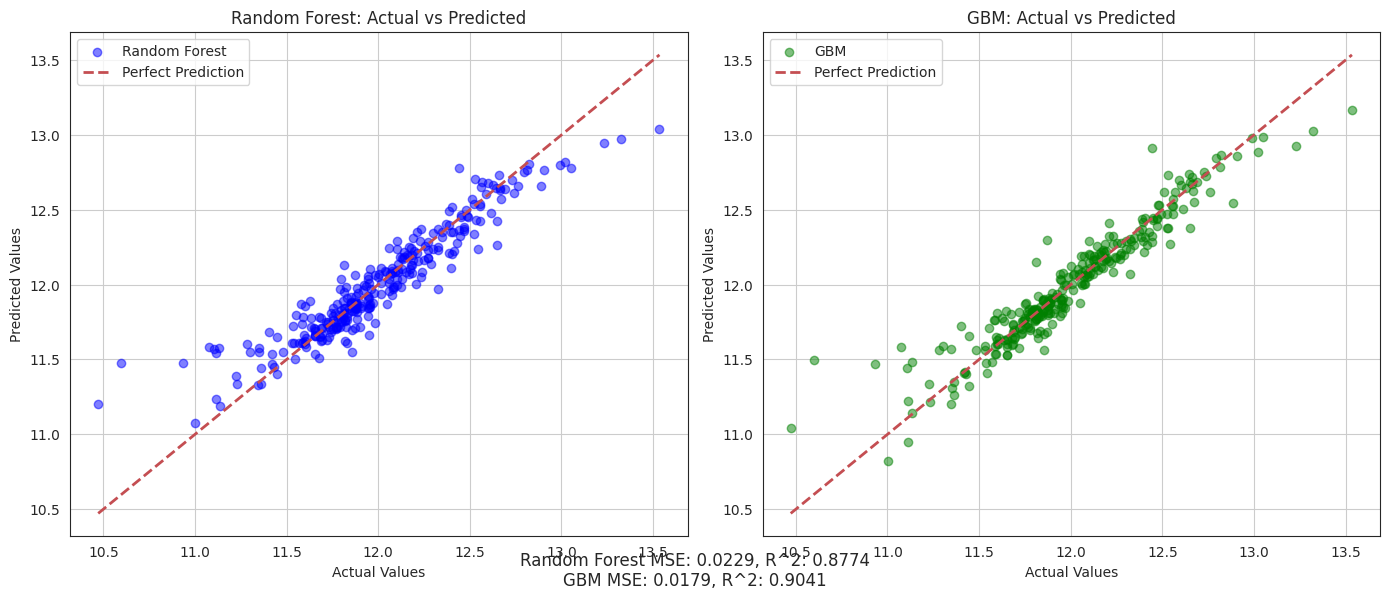

In [19]:
# Create plots
plt.figure(figsize=(14, 6))

# Random Forest Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, rf_predictions, color='blue', alpha=0.5, label='Random Forest')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.grid(True)

# GBM Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, gbr_predictions, color='green', alpha=0.5, label='GBM')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('GBM: Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.grid(True)

# Add text with performance metrics
plt.figtext(0.5, 0.04, f'Random Forest MSE: {0.0229:.4f}, R^2: {0.8774:.4f}\n'
                       f'GBM MSE: {0.0179:.4f}, R^2: {0.9041:.4f}', 
            ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
gbm_cv_scores = cross_val_score(gbr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Convert negative MSE scores to positive
rf_cv_scores = -rf_cv_scores
gbm_cv_scores = -gbm_cv_scores

# Print cross-validation results
print(f"Random Forest Cross-Validation MSE Scores: {rf_cv_scores}")
print(f"Random Forest Mean Cross-Validation MSE: {np.mean(rf_cv_scores)}")
print(f"Random Forest Std Dev of Cross-Validation MSE: {np.std(rf_cv_scores)}")

print(f"Gradient Boosting Machine Cross-Validation MSE Scores: {gbm_cv_scores}")
print(f"Gradient Boosting Machine Mean Cross-Validation MSE: {np.mean(gbm_cv_scores)}")
print(f"Gradient Boosting Machine Std Dev of Cross-Validation MSE: {np.std(gbm_cv_scores)}")

Random Forest Cross-Validation MSE Scores: [0.01756735 0.0269162  0.03186169 0.0205011  0.01435798]
Random Forest Mean Cross-Validation MSE: 0.02224086361882723
Random Forest Std Dev of Cross-Validation MSE: 0.006347085193609837
Gradient Boosting Machine Cross-Validation MSE Scores: [0.01327555 0.01682803 0.0193216  0.01339643 0.01004366]
Gradient Boosting Machine Mean Cross-Validation MSE: 0.014573054566945562
Gradient Boosting Machine Std Dev of Cross-Validation MSE: 0.0032005284680472097


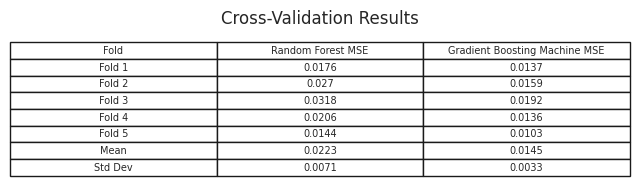

In [21]:
# Cross-validation scores rounded to 4 decimal places
rf_scores = [round(score, 4) for score in [0.01760428, 0.0270193, 0.03178231, 0.02061866, 0.01444294]]
gbm_scores = [round(score, 4) for score in [0.01369107, 0.01589345, 0.01916814, 0.01364441, 0.0102621]]

# Calculate mean and standard deviation, rounded to 4 decimal places
rf_mean = round(sum(rf_scores) / len(rf_scores), 4)
rf_std_dev = round(pd.Series(rf_scores).std(), 4)
gbm_mean = round(sum(gbm_scores) / len(gbm_scores), 4)
gbm_std_dev = round(pd.Series(gbm_scores).std(), 4)

# Create a DataFrame with the cross-validation scores and statistics
data_scores = {
    'Fold': [f'Fold {i+1}' for i in range(len(rf_scores))] + ['Mean', 'Std Dev'],
    'Random Forest MSE': rf_scores + [rf_mean, rf_std_dev],
    'Gradient Boosting Machine MSE': gbm_scores + [gbm_mean, gbm_std_dev]
}

df_scores = pd.DataFrame(data_scores)

# Create a figure and axis to display the table
fig, ax = plt.subplots(figsize=(8, 2))  # Adjust the figsize as needed
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_scores.values, colLabels=df_scores.columns, cellLoc='center', loc='center', 
                )

plt.title('Cross-Validation Results')
plt.show()

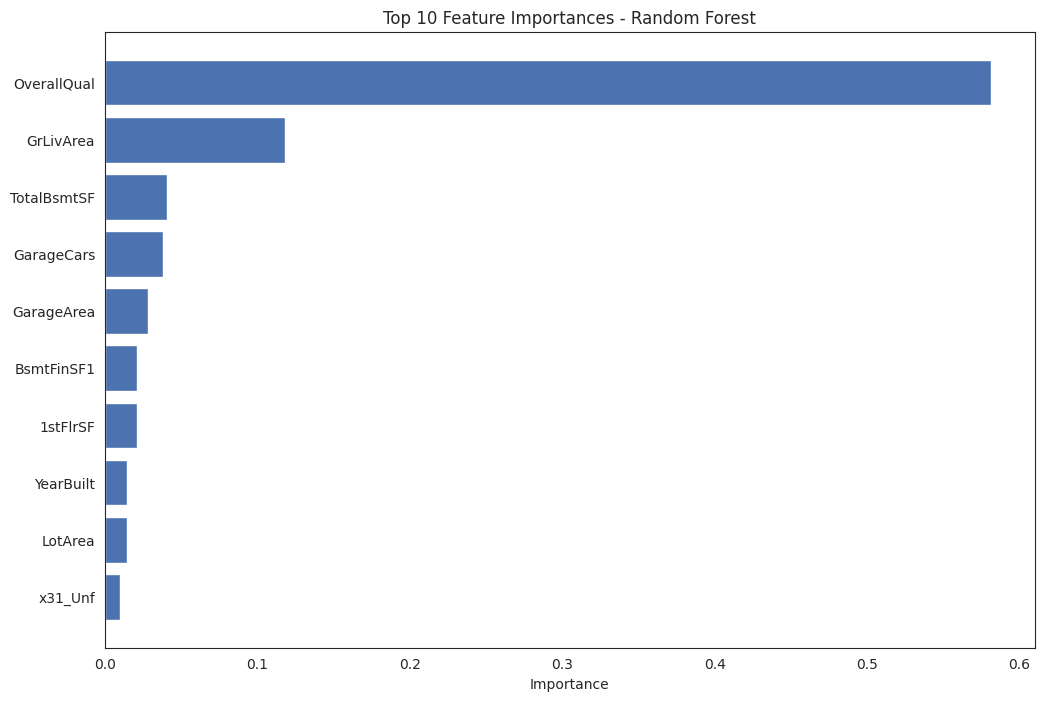

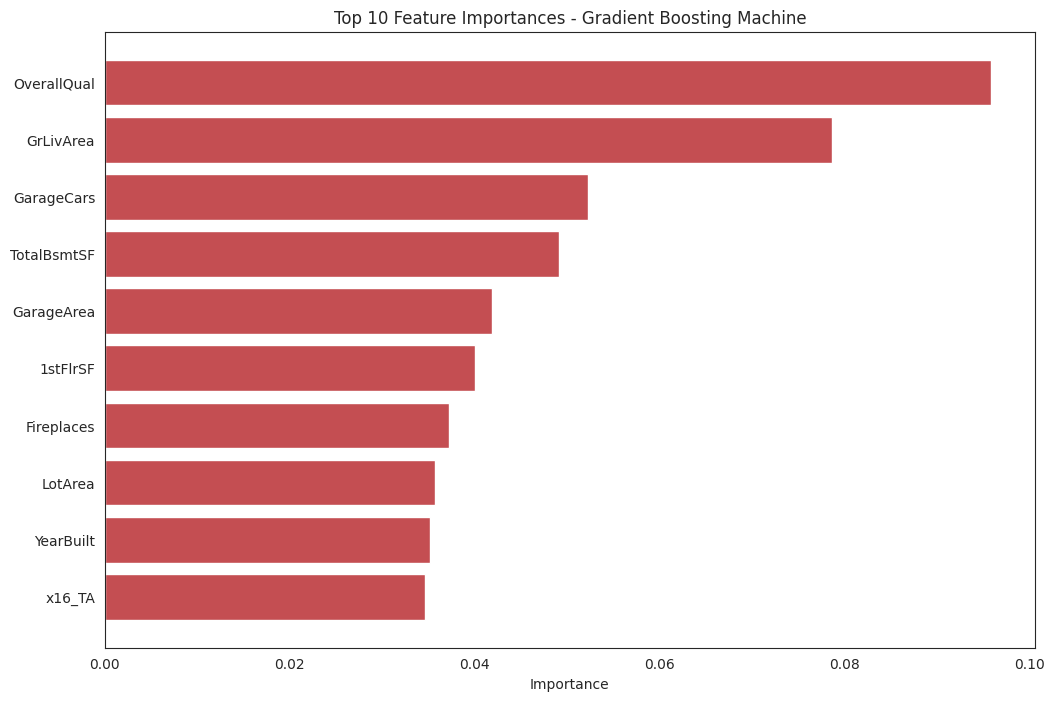

In [22]:
# Extract Random Forest model from pipeline
rf_model = rf_pipeline.named_steps['regressor']

# Extract Gradient Boosting Machine model from pipeline
gbr_model = gbr_pipeline.named_steps['regressor']

# Extract feature importances from Random Forest model
rf_importances = rf_model.feature_importances_

# Extract feature importances from Gradient Boosting Machine model
gbr_importances = gbr_model.feature_importances_

# Use the column transformer to get feature names after one-hot encoding
feature_names = numerical_cols.tolist() + list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out())

# Create a DataFrame for feature importances
importances_df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
importances_df_gbr = pd.DataFrame({'Feature': feature_names, 'Importance': gbr_importances})

# Sort the importances and select top 10
importances_df_rf = importances_df_rf.sort_values(by='Importance', ascending=False).head(10)
importances_df_gbr = importances_df_gbr.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 feature importances for Random Forest
plt.figure(figsize=(12, 8))
plt.title('Top 10 Feature Importances - Random Forest')
plt.barh(importances_df_rf['Feature'], importances_df_rf['Importance'], color='b')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

# Plot the top 10 feature importances for Gradient Boosting Machine
plt.figure(figsize=(12, 8))
plt.title('Top 10 Feature Importances - Gradient Boosting Machine')
plt.barh(importances_df_gbr['Feature'], importances_df_gbr['Importance'], color='r')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

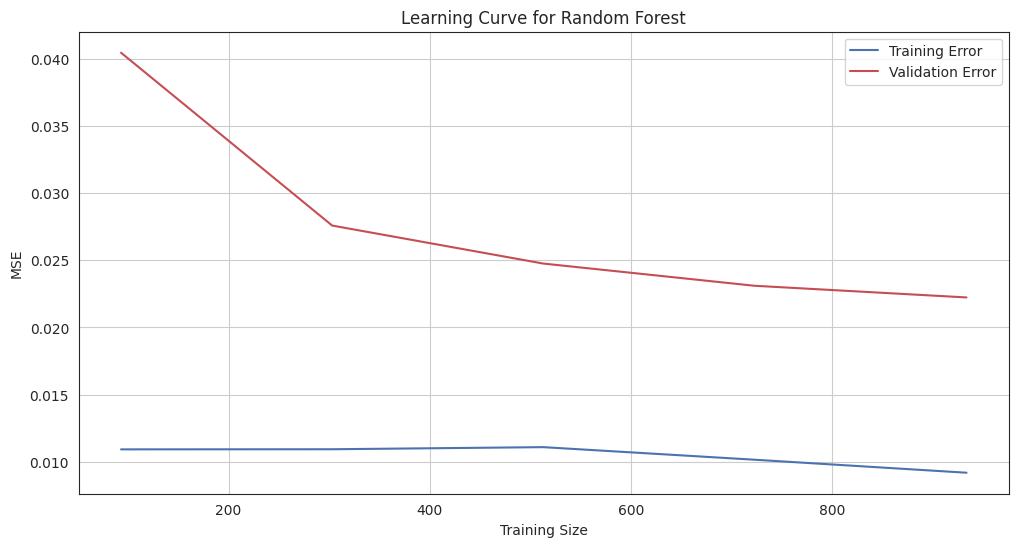

In [23]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    rf_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error', color='b')
plt.plot(train_sizes, -valid_scores.mean(axis=1), label='Validation Error', color='r')
plt.title('Learning Curve for Random Forest')
plt.xlabel('Training Size')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

train_sizes, train_scores, valid_scores = learning_curve(
    gbr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

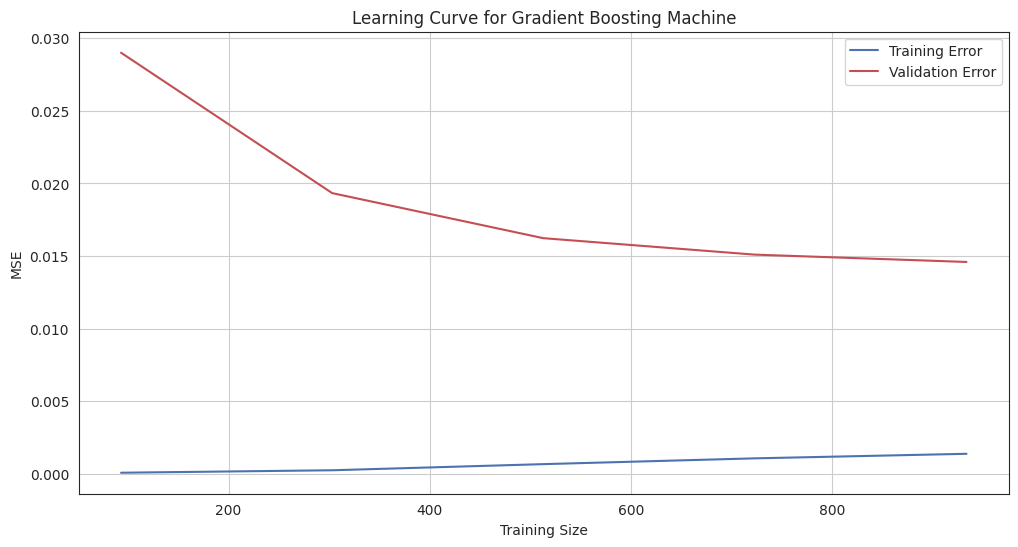

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error', color='b')
plt.plot(train_sizes, -valid_scores.mean(axis=1), label='Validation Error', color='r')
plt.title('Learning Curve for Gradient Boosting Machine')
plt.xlabel('Training Size')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()